# Model Evaluation and Testing
In this notebook, we load the trained model, visualize the training performance, and evaluate the results using a Confusion Matrix.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report

# Configuration
MODEL_PATH = "plant_disease_model.keras"
img_size = 128

# Load model and class names
model = load_model(MODEL_PATH)
class_indices = json.load(open("class_indices.json"))
class_names = list(class_indices.keys())

print("Model and class names loaded successfully!")

Model and class names loaded successfully!


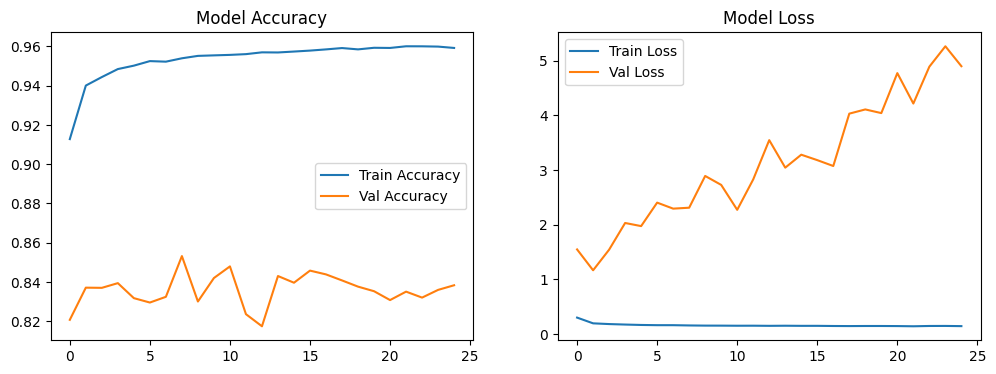

In [2]:
# Load history
with open('history.pkl', 'rb') as f:
    history = pickle.load(f)

# Plot Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

## Model Evaluation: Normalized Confusion Matrix
In this section, we evaluate the model's accuracy across all classes using a normalized confusion matrix to visualize potential misclassifications.

Found 32571 images belonging to 40 classes.
Calculating predictions...
1018/1018 ━━━━━━━━━━━━━━━━━━━━ 110s 107ms/step


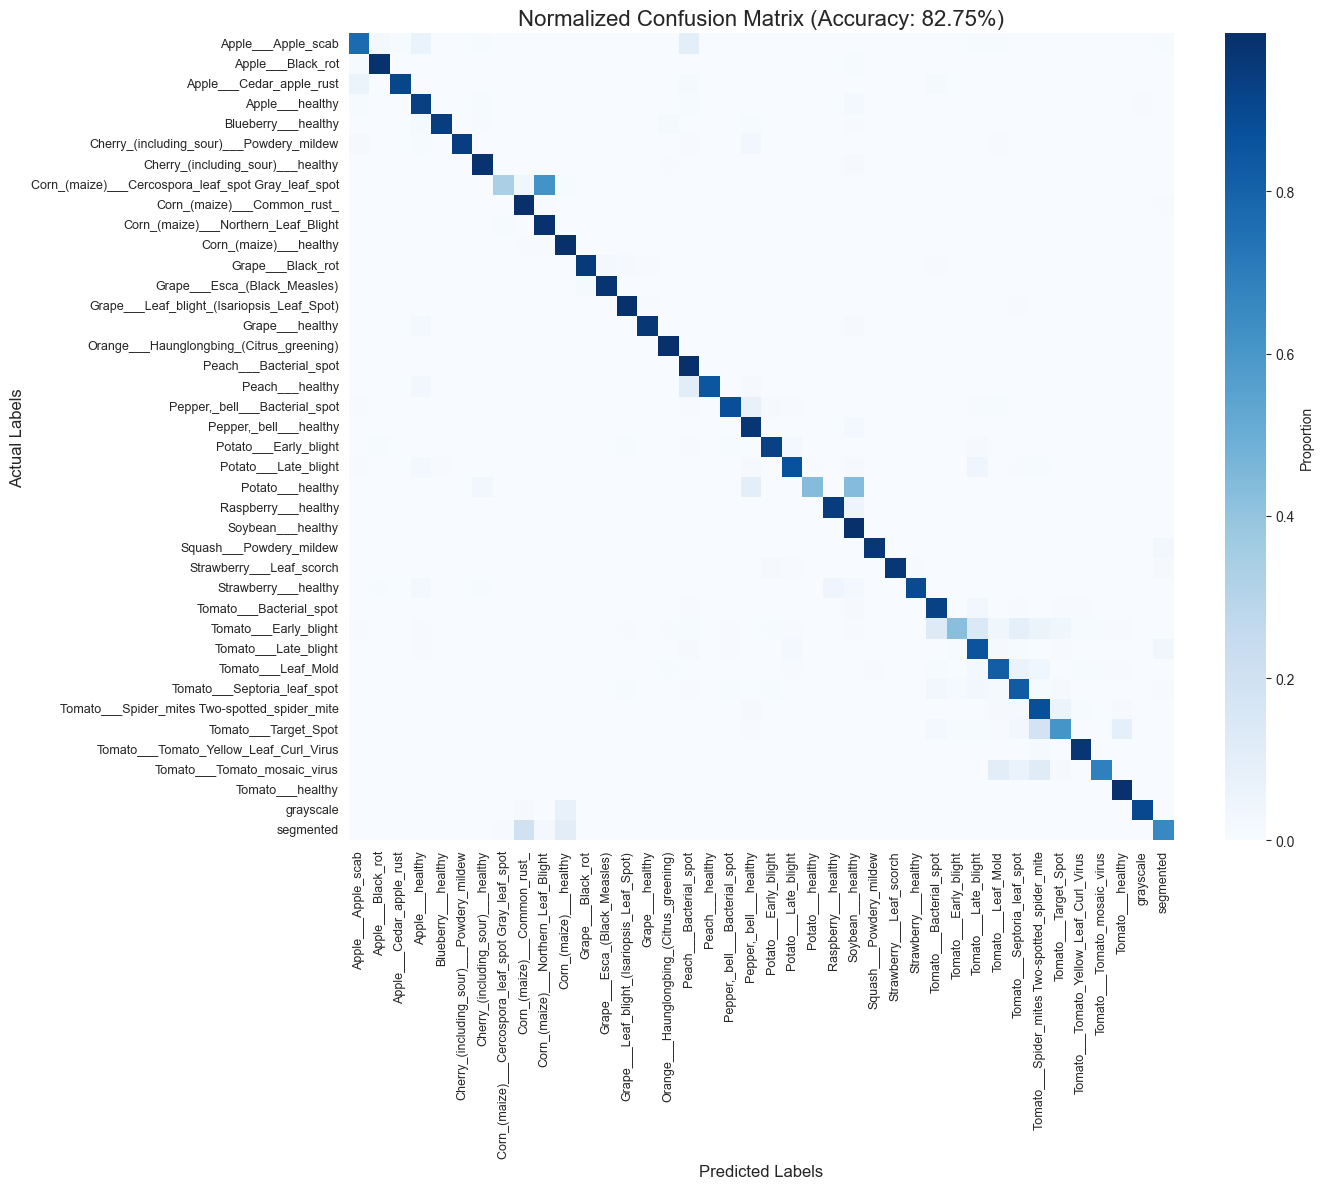

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix, accuracy_score

# --- Configuration ---
MODEL_PATH = "plant_disease_model.keras"
DATASET_PATH = r"C:\Users\Kanishka Kumar\OneDrive\Desktop\plant-diseases-cnn\Dataset"
CLASS_INDICES_PATH = "class_indices.json"
IMG_SIZE = 128
BATCH_SIZE = 32

# 1. Load Model and Class Names
model = load_model(MODEL_PATH)
with open(CLASS_INDICES_PATH, 'r') as f:
    class_indices = json.load(f)
class_names = list(class_indices.keys())

# 2. Prepare Validation Data
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, 
    validation_split=0.2
)

val_gen = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    subset="validation",
    shuffle=False 
)

# 3. Get Predictions
print("Calculating predictions...")
predictions = model.predict(val_gen)
y_pred = np.argmax(predictions, axis=1)
y_true = val_gen.classes

# 4. Calculate Accuracy and Normalized Confusion Matrix
acc = accuracy_score(y_true, y_pred) * 100
cm = confusion_matrix(y_true, y_pred, normalize='true')

# 5. Plotting
plt.figure(figsize=(14, 12))
sns.set_style("white")

ax = sns.heatmap(
    cm, 
    annot=False, 
    cmap="Blues", 
    cbar_kws={'label': 'Proportion'}, 
    xticklabels=class_names, 
    yticklabels=class_names
)

plt.title(f'Normalized Confusion Matrix (Accuracy: {acc:.2f}%)', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('Actual Labels', fontsize=12)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

plt.savefig('normalized_confusion_matrix.png', dpi=300)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step


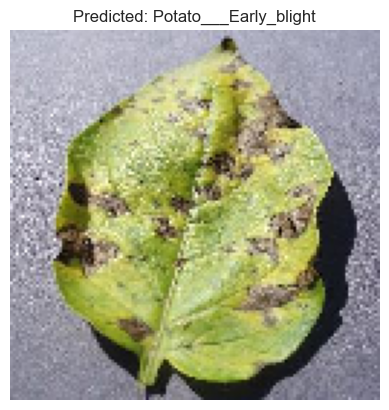

In [5]:
# Test on a single image
img_path = "C:/Users/Kanishka Kumar/OneDrive/Desktop/plant-diseases-cnn/Dataset/Potato___Early_blight/1de8ed75-0778-4364-9178-52c1bd0dffb4___RS_Early.B 6729.JPG"

img = image.load_img(img_path, target_size=(img_size, img_size))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

prediction = model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()